Total rows with best_mass>0:      739
Rows that FAIL to reject H0:      477
Rows that REJECT H0 (no region):  262

=== Derived IMF Slopes ===
All stars:              α = 1.23
Fail-to-reject H0 only: α = 1.37


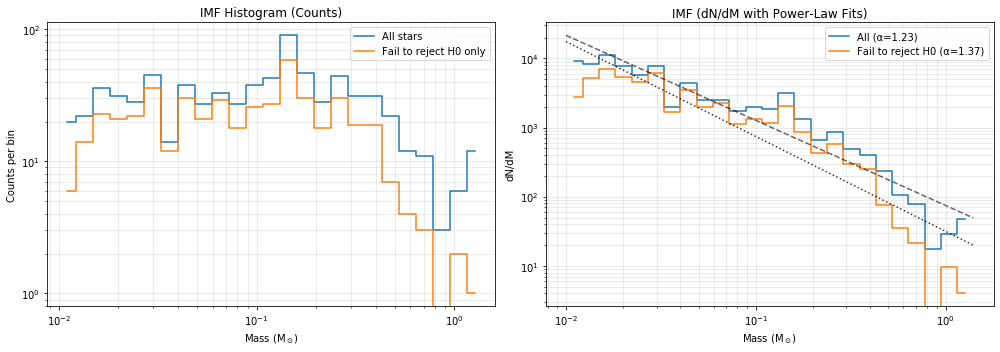

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load fit results ---
csv_path = "fit_results_jwst_hstall.csv"
df = pd.read_csv(csv_path)

# Basic sanity filtering
df = df.dropna(subset=["best_mass"])
df = df[df["best_mass"] > 0].copy()

# Terminology fix:
# bounds present => there exists a region with chi^2 <= chi^2_crit => FAIL TO REJECT H0 (model is consistent)
bounds_cols = ["mass_min","mass_max","AV_min","AV_max"]
df["fail_to_reject_H0"] = df[bounds_cols].notnull().all(axis=1)
df["reject_H0"] = ~df["fail_to_reject_H0"]

m_all = df["best_mass"].values
m_fail = df.loc[df["fail_to_reject_H0"], "best_mass"].values  # formerly your "reject_null=True" subset

print(f"Total rows with best_mass>0:      {len(m_all)}")
print(f"Rows that FAIL to reject H0:      {len(m_fail)}")
print(f"Rows that REJECT H0 (no region):  {df['reject_H0'].sum()}")

# --- IMF binning (log-spaced) ---
m_min = max(0.01, np.nanmin(m_all))
m_max = np.nanmax(m_all)
nbins = 25

bins = np.logspace(np.log10(m_min), np.log10(m_max), nbins + 1)

# --- Histograms ---
N_all, edges = np.histogram(m_all, bins=bins)
N_fail, _    = np.histogram(m_fail, bins=bins)

bin_centers = np.sqrt(edges[:-1] * edges[1:])
bin_widths  = edges[1:] - edges[:-1]

# dN/dM
dndm_all  = N_all  / bin_widths
dndm_fail = N_fail / bin_widths

# ---------------------------------------------------
# FIT IMF SLOPES (log–log linear regression)
# ---------------------------------------------------
def fit_imf_slope(mass, dndm):
    mask = (dndm > 0) & np.isfinite(dndm)
    logM = np.log10(mass[mask])
    logN = np.log10(dndm[mask])

    slope, intercept = np.polyfit(logM, logN, 1)
    alpha = -slope   # IMF convention
    return alpha, slope, intercept

alpha_all, slope_all, intercept_all   = fit_imf_slope(bin_centers, dndm_all)
alpha_fail, slope_fail, intercept_fail = fit_imf_slope(bin_centers, dndm_fail)

print("\n=== Derived IMF Slopes ===")
print(f"All stars:              α = {alpha_all:.2f}")
print(f"Fail-to-reject H0 only: α = {alpha_fail:.2f}")

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Counts ---
axes[0].step(bin_centers, N_all,  where="mid", label="All stars")
axes[0].step(bin_centers, N_fail, where="mid", label="Fail to reject H0 only")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mass (M$_\\odot$)")
axes[0].set_ylabel("Counts per bin")
axes[0].set_title("IMF Histogram (Counts)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

# --- dN/dM with fitted slopes ---
axes[1].step(bin_centers, dndm_all,  where="mid", label=f"All (α={alpha_all:.2f})")
axes[1].step(bin_centers, dndm_fail, where="mid", label=f"Fail to reject H0 (α={alpha_fail:.2f})")

# Overlay fitted power laws
M_fit = np.linspace(m_min, m_max, 200)
axes[1].plot(M_fit, 10**(intercept_all  + slope_all  * np.log10(M_fit)), "k--", alpha=0.6)
axes[1].plot(M_fit, 10**(intercept_fail + slope_fail * np.log10(M_fit)), "k:",  alpha=0.8)

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Mass (M$_\\odot$)")
axes[1].set_ylabel("dN/dM")
axes[1].set_title("IMF (dN/dM with Power-Law Fits)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Total rows with best_mass>0:      739
Rows that FAIL to reject H0:      477
Rows that REJECT H0 (no region):  262

Log-normal fit (ALL): mc = 0.094 Msun, sigma = 0.626 dex
Log-normal fit (FAIL to reject H0 only): mc = 0.083 Msun, sigma = 0.560 dex


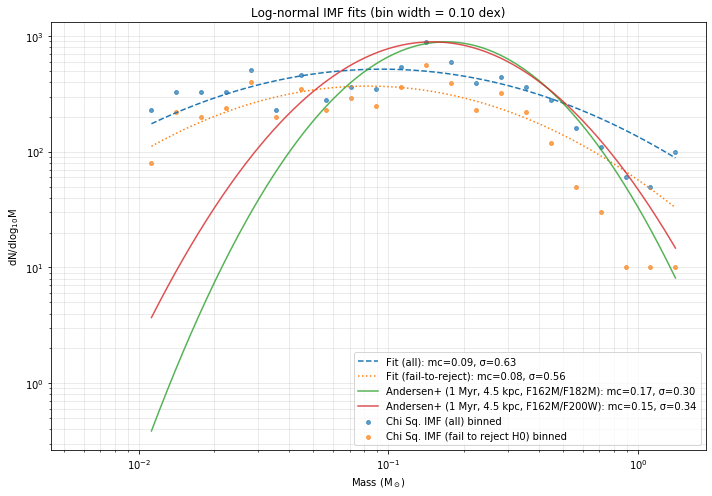

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- assumes you already created df, and df["fail_to_reject_H0"] in Cell 1 ---
# If not, uncomment below and re-run:
# csv_path = "fit_results_jwst_hstall.csv"
# df = pd.read_csv(csv_path)
# df = df.dropna(subset=["best_mass"])
# df = df[df["best_mass"] > 0].copy()
# bounds_cols = ["mass_min","mass_max","AV_min","AV_max"]
# df["fail_to_reject_H0"] = df[bounds_cols].notnull().all(axis=1)
# df["reject_H0"] = ~df["fail_to_reject_H0"]

m_all  = df["best_mass"].to_numpy()
m_fail = df.loc[df["fail_to_reject_H0"], "best_mass"].to_numpy()

print(f"Total rows with best_mass>0:      {len(m_all)}")
print(f"Rows that FAIL to reject H0:      {len(m_fail)}")
print(f"Rows that REJECT H0 (no region):  {df['reject_H0'].sum()}")

# ----------------------------
# Log-normal model in dN/dlog10M
# ----------------------------
def lognormal_dndlogM(M, A, log10_mc, sigma_dex):
    logM = np.log10(M)
    return A * np.exp(-0.5 * ((logM - log10_mc) / sigma_dex) ** 2)

def make_dndlogM(masses, bin_width_dex=0.1):
    masses = np.asarray(masses)
    masses = masses[np.isfinite(masses) & (masses > 0)]
    if len(masses) == 0:
        return None

    logM = np.log10(masses)
    lo = np.floor(logM.min() / bin_width_dex) * bin_width_dex
    hi = np.ceil(logM.max() / bin_width_dex) * bin_width_dex
    edges_log = np.arange(lo, hi + bin_width_dex, bin_width_dex)

    N, _ = np.histogram(logM, bins=edges_log)     # counts per log bin
    centers_log = 0.5 * (edges_log[:-1] + edges_log[1:])
    centers_M = 10 ** centers_log

    dlog = bin_width_dex
    dndlog = N / dlog  # dN/dlog10M
    return centers_M, dndlog, N, edges_log

def fit_lognormal(centers_M, dndlog):
    mask = (dndlog > 0) & np.isfinite(dndlog) & np.isfinite(centers_M) & (centers_M > 0)
    x = centers_M[mask]
    y = dndlog[mask]
    if len(x) < 3:
        return None

    A0 = np.nanmax(y)
    log10_mc0 = np.log10(x[np.nanargmax(y)])
    sigma0 = 0.3
    p0 = [A0, log10_mc0, sigma0]

    bounds = ([0.0, -5.0, 1e-3], [np.inf, 5.0, 2.0])
    popt, pcov = curve_fit(lognormal_dndlogM, x, y, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

# Build binned dN/dlogM
bin_width_dex = 0.1
all_binned  = make_dndlogM(m_all,  bin_width_dex=bin_width_dex)
fail_binned = make_dndlogM(m_fail, bin_width_dex=bin_width_dex)

# Fit
all_fit  = fit_lognormal(all_binned[0],  all_binned[1])  if all_binned  else None
fail_fit = fit_lognormal(fail_binned[0], fail_binned[1]) if fail_binned else None

if all_fit:
    (A_all, logmc_all, sig_all), _ = all_fit
    print(f"\nLog-normal fit (ALL): mc = {10**logmc_all:.3f} Msun, sigma = {sig_all:.3f} dex")
else:
    print("\nLog-normal fit (ALL): not enough points to fit")

if fail_fit:
    (A_fail, logmc_fail, sig_fail), _ = fail_fit
    print(f"Log-normal fit (FAIL to reject H0 only): mc = {10**logmc_fail:.3f} Msun, sigma = {sig_fail:.3f} dex")
else:
    print("Log-normal fit (FAIL to reject H0 only): not enough points to fit")

# ----------------------------
# Plot: dN/dlogM with fitted curves + Andersen comparison
# ----------------------------
plt.figure(figsize=(10, 7))

cent_all, dndlog_all, _, _ = all_binned
plt.scatter(cent_all, dndlog_all, s=15, alpha=0.7, label="Chi Sq. IMF (all) binned")

cent_fail, dndlog_fail, _, _ = fail_binned
plt.scatter(cent_fail, dndlog_fail, s=15, alpha=0.7, label="Chi Sq. IMF (fail to reject H0) binned")

M_plot = np.logspace(np.log10(min(cent_all.min(), cent_fail.min())),
                     np.log10(max(cent_all.max(), cent_fail.max())),
                     400)

if all_fit:
    plt.plot(M_plot, lognormal_dndlogM(M_plot, A_all, logmc_all, sig_all), linestyle="--",
             label=f"Fit (all): mc={10**logmc_all:.2f}, σ={sig_all:.2f}")
if fail_fit:
    plt.plot(M_plot, lognormal_dndlogM(M_plot, A_fail, logmc_fail, sig_fail), linestyle=":",
             label=f"Fit (fail-to-reject): mc={10**logmc_fail:.2f}, σ={sig_fail:.2f}")

# Andersen comparison (shape only; normalization scaled for visual overlay)
andersen_curves = [
    ("Andersen+ (1 Myr, 4.5 kpc, F162M/F182M)", 0.17, 0.30),
    ("Andersen+ (1 Myr, 4.5 kpc, F162M/F200W)", 0.15, 0.34),
]

A_scale = np.nanmax(dndlog_all) if np.any(np.isfinite(dndlog_all)) else 1.0
for label, mc, sig in andersen_curves:
    plt.plot(M_plot, lognormal_dndlogM(M_plot, A_scale, np.log10(mc), sig),
             alpha=0.8, label=f"{label}: mc={mc:.2f}, σ={sig:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (M$_\\odot$)")
plt.ylabel("dN/dlog$_{10}$M")
plt.title(f"Log-normal IMF fits (bin width = {bin_width_dex:.2f} dex)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()